In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

In [7]:
def davies_bouldin(data, k, labels, centroids):
    """
    davies_bouldin() : Computes the Davies-Bouldin index

    Parameters:
        data : pd.DataFrame of shape (n_samples, n_features)
        k : number of clusters
        labels : list, cluster labels
        centroids : list, centers for clusters

    Returns:
        DB index : float, lower values indicate better clustering
    """    

    # np array from pd df
    labels = np.array(labels)
    centroids = np.array(centroids)

    # compute Si: average dist of points in clusters to assigned centroid
    S = np.zeros(k)
    for i in range(k):
        # get points assigned to ith cluster
        cluster_pts = X[labels == i]
        
        if len(cluster_pts) > 0:
            # avg euclidean dist for each row of each centroid
            S[i] = np.mean(np.linalg.norm(cluster_pts - centroids[i], axis=1))  # axis=1 for row comparison
        # empty cluster
        else:
            S[i] = 0.0 
        
    # compute R = (Si + Sj) / dist between centroids
    # R is ratio of sum of centroids avg distances (scatter) to dist between centroids
    # (..dist between internal points compared to each other..?S)
    R = np.zeros(k)
    for i in range(k):
        max_r_ij = 0
        for j in range(k):
            # don't compare the same clusters
            if i != j:
                # euclidean dist between diff centroids
                dist_ij =  np.linalg.norm(centroids[i] - centroids[j])
                if dist_ij > 0:
                    r_ij = (S[i] + S[j]) / dist_ij
                    # large R_ij means high intercluster spread or clusters are too close together
                    # store cluster i is most similar to
                    if r_ij > max_r_ij:
                        max_r_ij = r_ij
            
            R[i] = max_r_ij
                    
    
    # compute mean of max of R for each cluster
    # bigger is worse
    DB_index = np.mean(R)
    
    return DB_index

def initialize_centroids(data):
    """
    initialize_centroids() : For each feature find out the minimum and maximum values. Then randomly
            select a value for each feature (using uniform distribution) from the min-max 
            range to initialize one complete centroid.

    Parameters:
        data: pd dataframe, dataset of features for analysis

    Returns:
        centroid: center for given data
    """
    num_features = data.shape[1] - 1
    centroid = np.zeros(num_features)

    for i in range(num_features):
        feature_min = data.iloc[:,i].min()
        feature_max = data.iloc[:,i].max()

        centroid[i] = np.random.uniform(low=feature_min, high=feature_max)
    
    return centroid

def calculate_inertia(data, centroids, labels):
    """
    calculate_inertia() : Finds the total inertia values at different k's

    Parameters:
        data: pd dataframe, dataset of features for analysis
        centroids: list, optimal cluster centers
        labels: list, associated centroids for each data point

    Returns:
        inertia: float, total distortion
    """
    X = data.iloc[:, :-1].values

    inertia = 0.0
    for i in range(len(X)):
        centroid = centroids[labels[i]]
        inertia += np.sum((X[i] - centroid) ** 2)

    return inertia


def find_opt_clusters(data, k, centroids, max_iters = 200, tolerance = 1e-6):
    """
    find_opt_clusters() : Calculates the best centroids for a given set of data and given 
                        k value

    Parameters:
        data: pd dataframe, dataset of features for analysis
        k: int, number of clusters
        centroids: list, centers for clusters
        max_iters: maximum iterations for finding opt centers
        tolerance: target error/difference between iterations

    Returns:
        centroids: optimal centers per cluster
        centroid_labels: best center for each data point
    """

    # remove label column
    X = np.array(data.iloc[:,:-1].values)
    
    centroids = np.array(centroids)

    for _ in range(max_iters):
        labels = np.zeros(len(X), dtype=int)

        # find closest centroid for each points
        for i in range(len(X)):
            dists = []
            for j in range(k):
                d = np.sum((X[i] - centroids[j]) ** 2)
                dists.append(d)
            
            # grabs index of smallest dist, which is the closest centroid
            labels[i] = np.argmin(dists)
        

        # initialize zeros matrix, matching current centroid shape
        new_centroids = np.zeros_like(centroids)

        # Re-compute centroids
        for j in range(k):
            # pull out each point that matches the label for the current cluster j
            cluster_points = X[labels == j]
            if len(cluster_points) > 0:
                # get a mean for each feature
                new_centroids[j] = np.mean(cluster_points, axis=0)
            else:
                # keep old center
                new_centroids[j] = centroids[j]

        # euclidean dist of centroids
        if np.linalg.norm(new_centroids-centroids) < tolerance:
            break
        
        centroids = new_centroids

    return centroids, labels

def elbow(data):
    """
    elbow() : Plots the inertias for different k's for the user to find the optimal
            number of clusters

    Parameters:
        data: pd dataframe, dataset of features for analysis

    Returns:
        None
    """
    num_features = data.shape[1] - 1
    k_min = 1
    k_max = num_features-1

    inertia_1 = []
    
    for i in range(k_min,k_max+1):
        centroids = []
        for j in range(i):
            centroids.append(initialize_centroids(data))

        centroids, centroid_labels = find_opt_clusters(data, i, centroids)

        inertia = calculate_inertia(data,centroids,centroid_labels)
        inertia_1.append(inertia)
    
    # Plotting stuff
    plt.figure()

    plt.plot(range(k_min,k_max+1), inertia_1, marker='o', label='Centroids')
    plt.title("Elbow Method")
    plt.xlabel("k")
    plt.ylabel("Inertia")

    plt.xticks(range(k_min,k_max+1))

    plt.grid(True)
    plt.legend()
    plt.show()

def calculate_purity(labels, true_labels):
    """
    calculate_purity() : Computes the purity for a given set of clusters

    Parameters:
        labels: predicted cluster labels
        true_labels: true class labels

    Returns:
        Purity: float, calculated purity
    """

    labels = np.array(labels)
    true_labels = np.array(true_labels)
    # find number of classes
    cluster_ids = np.unique(labels)

    total_correct = 0
    for cluster in cluster_ids:
        # find points associated with current cluster
        cluster_points = true_labels[labels == cluster]

        # if no points assigned to cluster, move on
        if len(cluster_points) == 0:
            continue
        
        # how many points in the cluster have true labels
        counts = np.bincount(cluster_points)

        # find majority correct class
        majority = counts.max()

        # sum max overlap over all clusters
        total_correct += majority

    purity = total_correct / len(labels)

    return purity

def visualize_pca(data, label="label"):
    """
    visualize_pca() : Performs PCA and chooses either 2 or 3 componenets to plot so
                    that cumulative variance >= 0.95. PLots a 2D or 3D plot depending on
                    number of components chosen.

    Parameters:
        data: pd dataframe, dataset of features for analysis

    Returns:
        None
    """
    X = data.iloc[:, :-1].values
    y = data[label].values
    n = X.shape[0]

    X_mean_centered = X - np.mean(X, axis=0)

    # covariance matrix
    S = (X_mean_centered.T @ X_mean_centered) / (n-1)

    # Eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eigh(S)

    # sort eigenvectors for eigenvalue
    # argsort() returns indeces of sorted array
    sorted_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_idx]
    eigenvectors = eigenvectors[:, sorted_idx]

    # Normalize eigenvalues
    eigenvalues_norm = eigenvalues / np.sum(eigenvalues)

    # Determine if top 2 or 3 dimensions are needed for sum var >= 0.95
    cumulative_sum = np.cumsum(eigenvalues_norm)

    if cumulative_sum[1] >= 0.95:
        dim = 3
    else:
        dim = 3
    
    print(f"Selected PCA dimensions: {dim}")
    print(f"Cumulative normalized variance: {cumulative_sum[:dim]}")

    # grab necessary components
    components = eigenvectors[:, :dim]

    # Visualize the data
    X_pca = X_mean_centered @ components

    if dim == 2:
        plt.figure()
        # for each class, assign labels
        for c in np.unique(y):
            plt.scatter(
                X_pca[y == c, 0],
                X_pca[y == c, 1],
                label=f"Class {c}",
                alpha=0.7,
            )

        # Plotting stuff
        plt.title("PCA Projection (2D) - Variance ≥ 95%")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.grid(True)
        plt.legend()
        plt.show()
    else: 
    # dim = 3
        fig = plt.figure()
        # still one plot, but tells matplotlib 3d is needed
        ax = fig.add_subplot(111, projection="3d")

        # for each class, assign labels
        for c in np.unique(y):
            ax.scatter(
                X_pca[y == c, 0],
                X_pca[y == c, 1],
                X_pca[y == c, 2],
                label=f"Class {c}",
                alpha=0.7,
            )

        # PLotting stuff
        ax.set_title("PCA Projection (3D) - Variance ≥ 95%")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        ax.legend()
        plt.show()
        

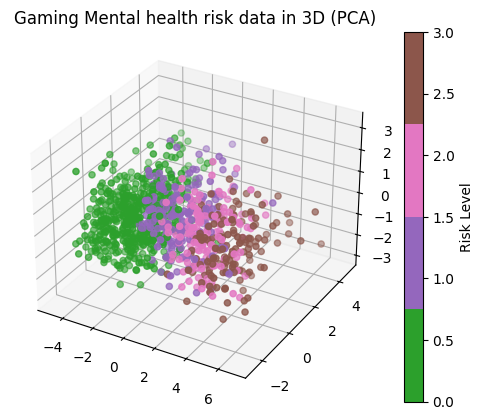

In [8]:
DATA_PATH = "../data/GamingandMentalHealth_final.csv"
# load data
data = pd.read_csv(DATA_PATH)

# convert to numpy
data = data.to_numpy()

# split features and target
x = data[:, 0:-1]
target = data[:, -1]

# scale features
scaler = StandardScaler()
xscaled = scaler.fit_transform(x)

# PCA
ndims = 3
pca = PCA(n_components=ndims)
result_pca = pca.fit_transform(xscaled)

# convert to DataFrame for plotting
result_pca = pd.DataFrame({
    'PCA_col1': result_pca[:, 0],
    'PCA_col2': result_pca[:, 1],
    'PCA_col3': result_pca[:, 2],
    'GamingMentalHealth': target
})

# 3D plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

cmap = ListedColormap(['tab:green','tab:purple','tab:pink','tab:brown'])

img = ax.scatter(
    xs=result_pca['PCA_col1'],
    ys=result_pca['PCA_col2'],
    zs=result_pca['PCA_col3'],
    c=result_pca['GamingMentalHealth'],
    cmap=cmap
)

plt.title("Gaming Mental health risk data in 3D (PCA)")
fig.colorbar(img, ax=ax, label='Risk Level')
plt.show()

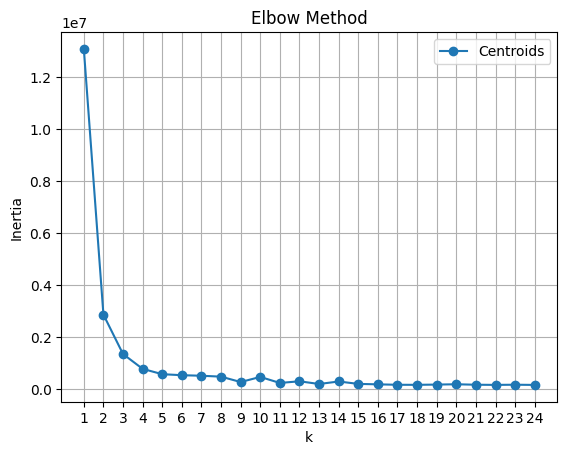

In [4]:
# import dataset
dataset = pd.read_csv(DATA_PATH)

# Use elbow method to find optimal number of clusters, k
# Visualization of elbow method
elbow(dataset)


(1000, 25)
DB Index = 0.5051021991473928 for k = 3
Purity (k=3): 0.638


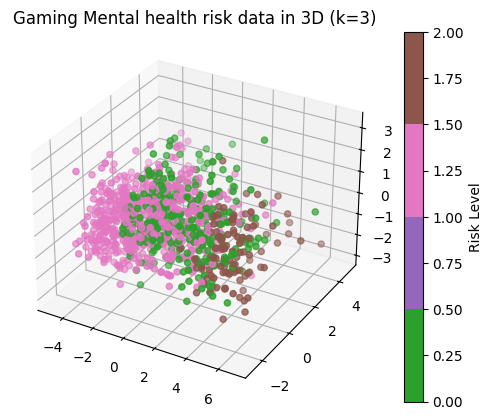

DB Index = 0.5317993401708362 for k = 4
Purity (k=4): 0.62


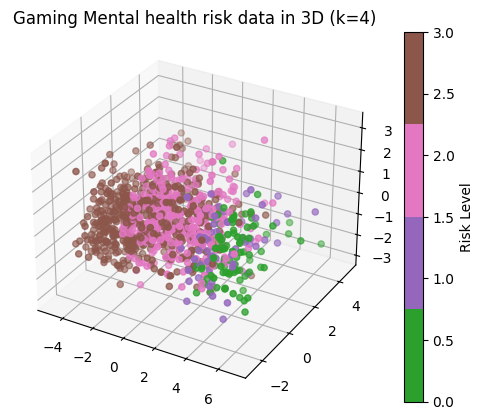

In [ ]:

X = dataset.iloc[:, :-1].values
y = dataset["gaming_addiction_risk_level"].values
# find the purity for each k
k = 3

centroids3 = []
for j in range(k):
    centroids3.append(initialize_centroids(dataset))

centroids_3, labels3 = find_opt_clusters(dataset, k, centroids3)
purity3 = calculate_purity(dataset["gaming_addiction_risk_level"].values, labels3)

db_index = davies_bouldin(X, k, labels3, centroids_3)
print(f"DB Index = {db_index} for k = {k}")
print(f"Purity (k=3): {purity3}")


# 3D plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

cmap = ListedColormap(['tab:green','tab:purple','tab:pink','tab:brown'])

img = ax.scatter(
    xs=result_pca['PCA_col1'],
    ys=result_pca['PCA_col2'],
    zs=result_pca['PCA_col3'],
    c=labels3,
    cmap=cmap
)

plt.title("Gaming Mental health risk data in 3D (k=3)")
fig.colorbar(img, ax=ax, label='Risk Level')
plt.show()


k = 4

centroids4 = []
for j in range(k):
    centroids4.append(initialize_centroids(dataset))

centroids_4, labels4 = find_opt_clusters(dataset, k, centroids4)
purity4 = calculate_purity(dataset["gaming_addiction_risk_level"].values, labels4)
db_index = davies_bouldin(X, k, labels4, centroids_4)
print(f"DB Index = {db_index} for k = {k}")
print(f"Purity (k=4): {purity4}")

# 3D plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

cmap = ListedColormap(['tab:green','tab:purple','tab:pink','tab:brown'])

img = ax.scatter(
    xs=result_pca['PCA_col1'],
    ys=result_pca['PCA_col2'],
    zs=result_pca['PCA_col3'],
    c=labels4,
    cmap=cmap
)

plt.title("Gaming Mental health risk data in 3D (k=4)")
fig.colorbar(img, ax=ax, label='Risk Level')
plt.show()